In [3]:
import pandas as pd
import pingouin as pg

In [4]:
df = pd.read_csv("KODIS_personality.csv")
df

,Unnamed: 0,kodis-id,buyer or seller,extroversion_score,agreeableness_score,conscientiousness_score,neuroticism_score,openness_score
0,0,2523,buyer,3.0,3.5,3.5,2.0,3.5
1,1,2523,seller,3.5,4.0,5.0,3.5,2.0
2,2,2525,buyer,2.5,2.5,4.5,3.0,5.0
3,3,2525,seller,1.5,3.5,3.5,2.5,5.0
4,4,2526,buyer,1.5,3.5,4.5,3.0,4.5
...,...,...,...,...,...,...,...,...
435,435,2879,seller,2.5,4.5,5.0,2.0,4.0
436,436,2881,buyer,3.0,4.5,5.0,2.0,3.0
437,437,2881,seller,1.5,4.5,5.0,1.0,4.5
438,438,2889,buyer,3.0,4.0,3.5,2.5,3.0


In [5]:
df_buyer = df[df["buyer or seller"] == "buyer"]
df_seller = df[df["buyer or seller"] == "seller"]
df_buyer

,Unnamed: 0,kodis-id,buyer or seller,extroversion_score,agreeableness_score,conscientiousness_score,neuroticism_score,openness_score
0,0,2523,buyer,3.0,3.5,3.5,2.0,3.5
2,2,2525,buyer,2.5,2.5,4.5,3.0,5.0
4,4,2526,buyer,1.5,3.5,4.5,3.0,4.5
6,6,2527,buyer,1.5,2.5,5.0,3.5,4.5
8,8,2528,buyer,3.5,5.0,4.0,2.0,3.5
...,...,...,...,...,...,...,...,...
430,430,2875,buyer,3.5,4.0,4.0,2.0,4.0
432,432,2878,buyer,2.5,4.5,5.0,4.0,4.0
434,434,2879,buyer,3.0,2.0,3.0,5.0,3.5
436,436,2881,buyer,3.0,4.5,5.0,2.0,3.0


In [6]:
liwc_categories = list(df.columns[4:-5])
liwc_categories

[]

(array([19., 22., 28., 32.,  0., 34., 30., 25., 15., 13.]),
 array([1. , 1.4, 1.8, 2.2, 2.6, 3. , 3.4, 3.8, 4.2, 4.6, 5. ]),
 <BarContainer object of 10 artists>)

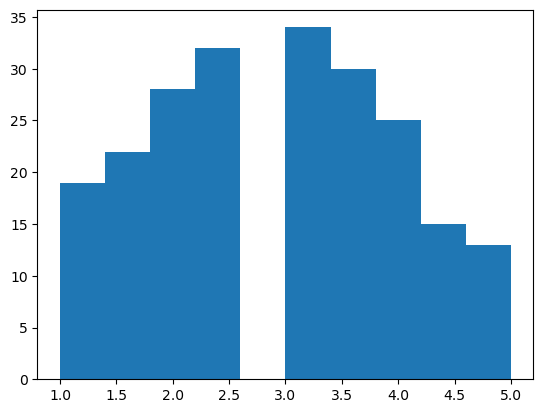

In [7]:
import matplotlib.pyplot as plt

plt.hist(df_seller["neuroticism_score"])

In order to run Pearson's correlation on the data, both IV and DV must be normally distributed. You can call Pingouin's normality function to check. If normal == False, then you should use Spearman's Rank correlation.

In [73]:
pg.normality(df_buyer["openness_score"])

,W,pval,normal
openness_score,0.946937,3.433417e-07,False


In [84]:
side = df_buyer
iv = "openness_score"

for liwc_category in liwc_categories:
    o = dict(pg.corr(side[iv], side[liwc_category], method="spearman"))
    pval = o["p-val"]["spearman"]
    r = o["r"]["spearman"]
    n = o["n"]["spearman"]
    if pval < 0.05:
        print(f"Significant value found for {liwc_category}: n = {n}, r = {r:.2f} and pval = {pval:.2f}")
        #print(f"{liwc_category}")
        #print(f"{r:.2f}, p={pval:.2f}")


Significant value found for you: n = 219, r = 0.14 and pval = 0.03
Significant value found for verb: n = 219, r = -0.14 and pval = 0.03
Significant value found for emotion: n = 219, r = 0.14 and pval = 0.04
Significant value found for moral: n = 219, r = 0.16 and pval = 0.02
Significant value found for work: n = 219, r = 0.14 and pval = 0.05
Significant value found for relig: n = 219, r = 0.14 and pval = 0.04
Significant value found for lack: n = 219, r = -0.18 and pval = 0.01
Significant value found for Conversation: n = 219, r = -0.15 and pval = 0.03
Significant value found for assent: n = 219, r = -0.13 and pval = 0.05


/Users/kaleenshrestha/anaconda3/envs/personality-conflict/lib/python3.12/site-packages/pingouin/correlation.py:606: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pval = spearmanr(x, y, **kwargs)
/Users/kaleenshrestha/anaconda3/envs/personality-conflict/lib/python3.12/site-packages/pingouin/correlation.py:606: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pval = spearmanr(x, y, **kwargs)
/Users/kaleenshrestha/anaconda3/envs/personality-conflict/lib/python3.12/site-packages/pingouin/correlation.py:606: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pval = spearmanr(x, y, **kwargs)
/Users/kaleenshrestha/anaconda3/envs/personality-conflict/lib/python3.12/site-packages/pingouin/correlation.py:606: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pval = spearmanr(x, y, **kwargs)


# Adding Personality info

In [2]:
df_liwc = pd.read_csv("Jennifer_LIWC-22-Results_processed_conversations_LIWC Analysis.csv")
df_kodis_human_human = pd.read_csv("../KODIS-human-human-subset.csv")

In [3]:
set(df_liwc["kodis-id"]) == set(df_kodis_human_human["Unnamed: 0"])

True

In [12]:
float(df_kodis_human_human[df_kodis_human_human["Unnamed: 0"]==2523][f"b_Personality_1"].iloc[0])

3.0

In [6]:
def reverse_bfi_10(num: int):
    return 6-num

In [14]:
extroversion_col, agreeableness_col, conscientiousness_col, neuroticism_col, openness_col = [], [], [], [], []
for _, row in df_liwc.iterrows():
    id = row["kodis-id"]
    speaker = "b" if row["buyer or seller"] == "buyer" else "s"
    kodis_data = df_kodis_human_human[df_kodis_human_human["Unnamed: 0"]==id]
    # calculate BFI-10 based on scoring manual: https://socialwork.buffalo.edu/content/dam/socialwork/home/self-care-kit/brief-big-five-personality-inventory.pdf
    extroversion = (reverse_bfi_10(float(kodis_data[f"{speaker}_Personality_{1}"].iloc[0])) + float(kodis_data[f"{speaker}_Personality_{5}"].iloc[0]))/2
    agreeableness = (reverse_bfi_10(float(kodis_data[f"{speaker}_Personality_{7}"].iloc[0])) + float(kodis_data[f"{speaker}_Personality_{2}"].iloc[0]))/2
    conscientiousness = (reverse_bfi_10(float(kodis_data[f"{speaker}_Personality_{3}"].iloc[0])) + float(kodis_data[f"{speaker}_Personality_{8}"].iloc[0]))/2
    neuroticism = (reverse_bfi_10(float(kodis_data[f"{speaker}_Personality_{4}"].iloc[0])) + float(kodis_data[f"{speaker}_Personality_{9}"].iloc[0]))/2
    openness = (reverse_bfi_10(float(kodis_data[f"{speaker}_Personality_{5}"].iloc[0])) + float(kodis_data[f"{speaker}_Personality_{10}"].iloc[0]))/2
    
    extroversion_col.append(extroversion)
    agreeableness_col.append(agreeableness)
    conscientiousness_col.append(conscientiousness)
    neuroticism_col.append(neuroticism)
    openness_col.append(openness)

# df_kodis_human_human[f"b_Personality_{1}"]

In [15]:
df_liwc["extroversion_score"] = extroversion_col
df_liwc["agreeableness_score"] = agreeableness_col
df_liwc["conscientiousness_score"] = conscientiousness_col
df_liwc["neuroticism_score"] = neuroticism_col
df_liwc["openness_score"] = openness_col

In [16]:
df_liwc

,kodis-id,buyer or seller,Segment,WC,Analytic,Clout,Authentic,Tone,WPS,BigWords,...,QMark,Exclam,Apostro,OtherP,Emoji,extroversion_score,agreeableness_score,conscientiousness_score,neuroticism_score,openness_score
0,2523,buyer,1,257,7.66,3.36,48.39,43.41,17.13,15.18,...,0.39,0.0,0.39,0.39,0.0,3.0,3.5,3.5,2.0,3.5
1,2523,seller,1,102,3.68,96.50,6.58,80.19,17.00,16.67,...,0.00,0.0,1.96,0.00,0.0,3.5,4.0,5.0,3.5,2.0
2,2525,buyer,1,112,13.27,1.00,99.00,47.30,10.18,18.75,...,0.00,0.0,0.00,0.89,0.0,2.5,2.5,4.5,3.0,5.0
3,2525,seller,1,156,38.20,84.23,53.41,8.34,10.40,13.46,...,3.85,0.0,0.00,0.00,0.0,1.5,3.5,3.5,2.5,5.0
4,2526,buyer,1,69,43.12,2.33,74.45,99.00,69.00,13.04,...,0.00,0.0,0.00,0.00,0.0,1.5,3.5,4.5,3.0,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
435,2879,seller,1,203,3.00,17.89,84.21,4.68,50.75,7.88,...,0.00,0.0,0.00,0.00,0.0,2.5,4.5,5.0,2.0,4.0
436,2881,buyer,1,64,1.00,7.67,54.55,88.05,9.14,17.19,...,1.56,0.0,3.13,0.00,0.0,3.0,4.5,5.0,2.0,3.0
437,2881,seller,1,166,16.29,94.09,66.60,98.79,11.07,15.66,...,3.01,0.6,1.81,0.00,0.0,1.5,4.5,5.0,1.0,4.5
438,2889,buyer,1,254,12.26,49.43,76.20,91.33,23.09,13.39,...,1.18,0.0,0.39,0.79,0.0,3.0,4.0,3.5,2.5,3.0


In [29]:
df_liwc.to_csv("LIWC_WITH_PERSONALITY.csv")